**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding = 'ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


**Check Missing Data**

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Cleaning

Remove Missing CustomerID

In [17]:
df = df.dropna(subset = ['CustomerID'])

In [8]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


Remove Negative Quantity(Returns)

In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


**Remove Duplicates**

In [25]:
df.drop_duplicates(inplace = True)

**Convert Date Column**

In [27]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature Engineering 

In [39]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [40]:
df['TotalPrice']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 392732, dtype: float64

In [32]:
df['month'] = df['InvoiceDate'].dt.month

In [33]:
df['month']

0         12
1         12
2         12
3         12
4         12
          ..
541904    12
541905    12
541906    12
541907    12
541908    12
Name: month, Length: 392732, dtype: int32

In [34]:
df['year'] = df['InvoiceDate'].dt.year

In [35]:
df['year']

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
541904    2011
541905    2011
541906    2011
541907    2011
541908    2011
Name: year, Length: 392732, dtype: int32

# Analysis

**Total Revenue**

In [45]:
total_revenue = df['TotalPrice'].sum()

In [46]:
total_revenue

np.float64(8887208.894)

**Top Products**

In [43]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending = False).head(10)

In [47]:
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

**Sales by Country**

In [49]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending = False)

In [50]:
country_sales

Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208934.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

**Monthly Sales**

In [52]:
monthly_sales = df.groupby('month')['TotalPrice'].sum()

In [54]:
monthly_sales

month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

# Visualization

**Monthly Trend**

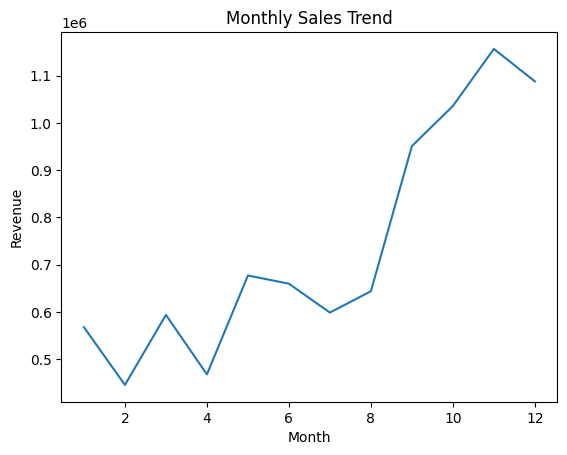

In [58]:
monthly_sales.plot(kind = 'line')
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.xlabel('Month')
plt.show()

**Top Products**

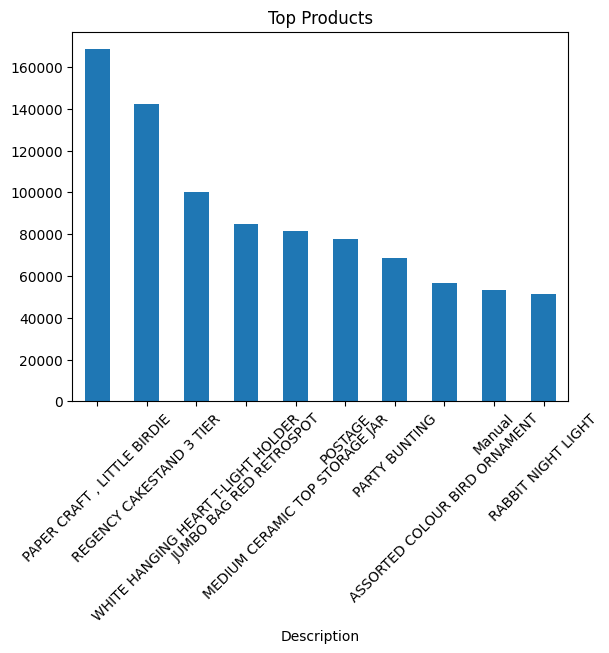

In [60]:
top_products.plot(kind = 'bar')
plt.title('Top Products')
plt.xticks(rotation = 45)
plt.show()

**Country Sales**

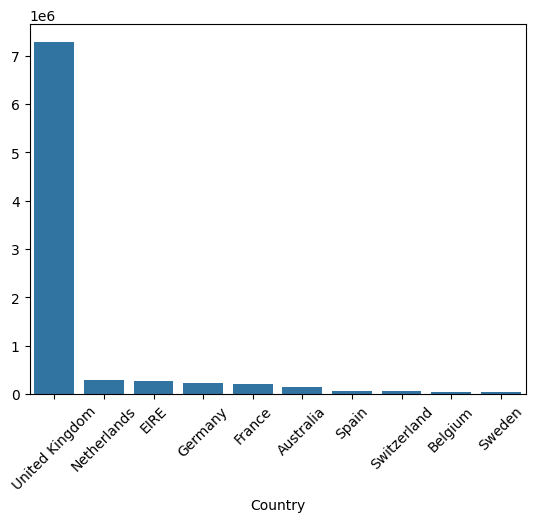

In [61]:
sns.barplot(x = country_sales.head(10).index, y = country_sales.head(10).values)
plt.xticks(rotation = 45)
plt.show()

In [ ]:
import datetime as dt

today = df['InvoiceDate'].max() # find the latest date in the dataset 

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (today - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# RFM Chart 

**Distribution of Customers**

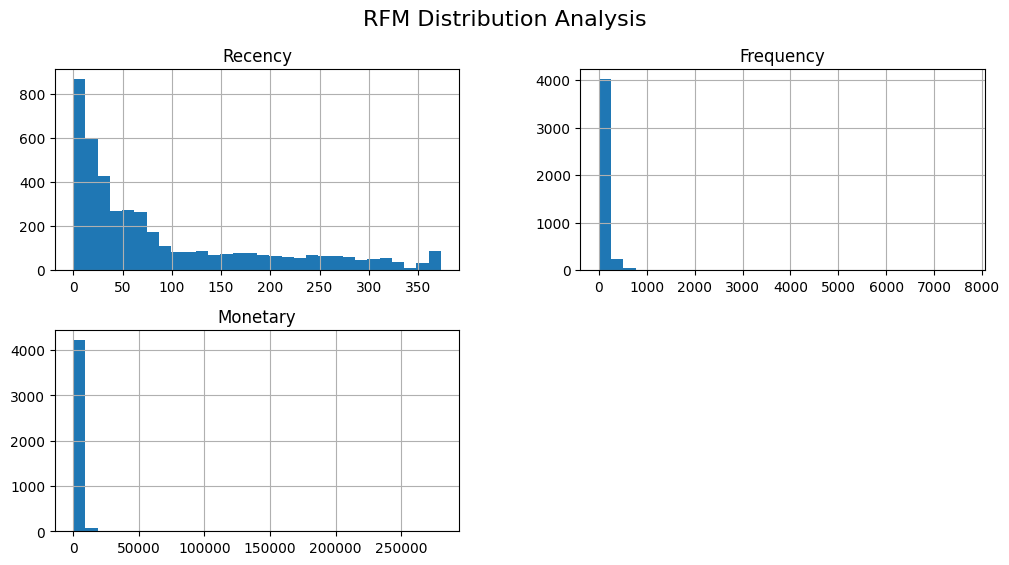

In [64]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(figsize=(12,6), bins=30)
plt.suptitle("RFM Distribution Analysis", fontsize=16)
plt.show()

# RFM Distribution Analysis ---- Key Insights

1. **Recency**
- Many Customers purchased recently
- But there is also a group of inactive customers

2. **Frequency**
- Most customers are one time or occasional buyers 
- Only a small group are loyal customers

3. **Monetary**
- Revenue is heavily skewed
- Few customers spend very high amounts (outliers)

The analysis reveals that while most customers are recent and low-frequency buyers with low spending, a small segment of customers contributes significantly to revenue. This indicates an opportunity to focus on retaining high-value customers and converting low-frequency customers into repeat buyers

**Recency Vs Monetary**

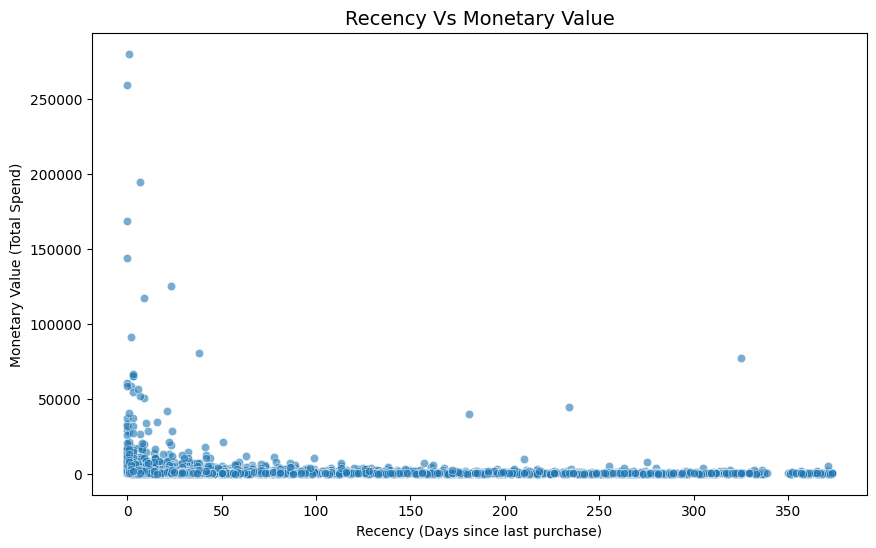

In [66]:
plt.figure(figsize = (10,6))
sns.scatterplot(
    x = "Recency",
    y = "Monetary",
    data = rfm,
    alpha = 0.6
)

plt.title("Recency Vs Monetary Value", fontsize = 14)
plt.xlabel("Recency (Days since last purchase)")
plt.ylabel("Monetary Value (Total Spend)")
plt.show()

**Frequency Vs Monetary**

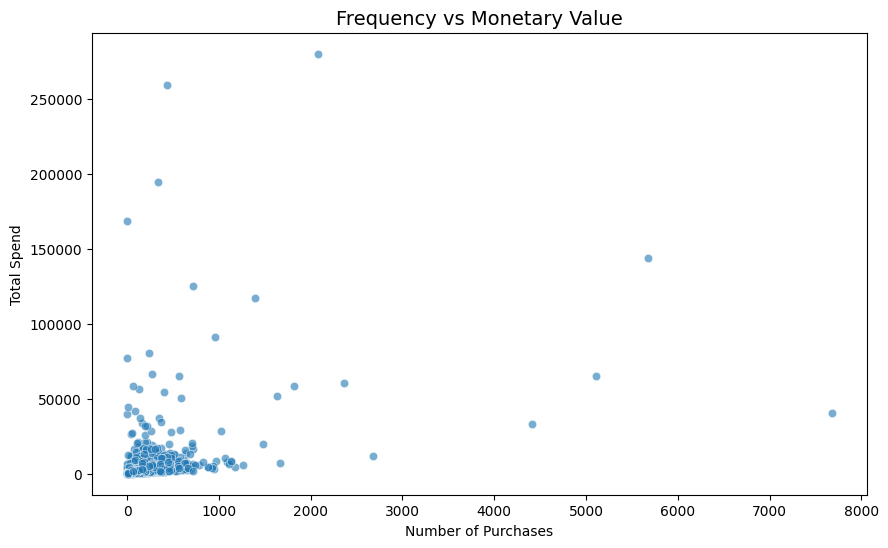

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Frequency',
    y='Monetary',
    data=rfm,
    alpha=0.6
)

plt.title("Frequency vs Monetary Value", fontsize=14)
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spend")
plt.show()

**Correlation Heatmap**

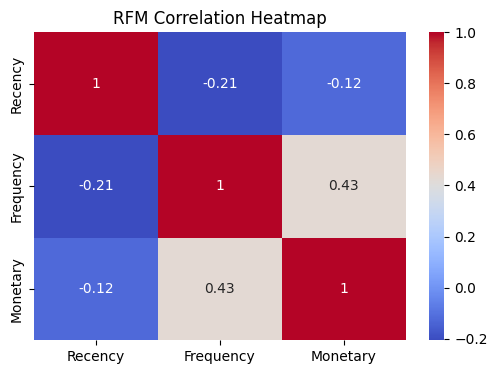

In [69]:
plt.figure(figsize=(6,4))
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title("RFM Correlation Heatmap")
plt.show()

**Top 5 Customesrs**

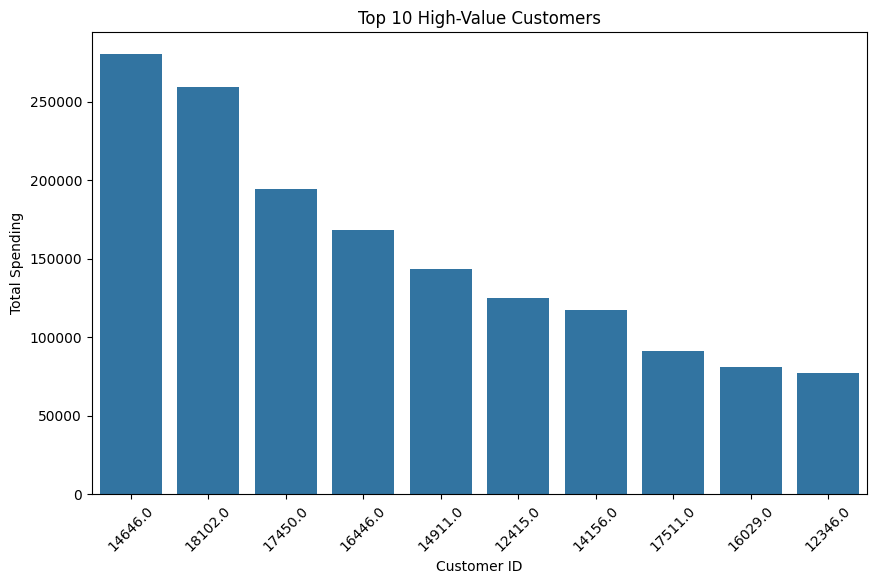

In [71]:
top_customers = rfm.sort_values(by='Monetary', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.index.astype(str), y=top_customers['Monetary'])

plt.title("Top 10 High-Value Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()